
# Sales prediction model

Ce projet s'appuie sur les données de Walmart, une multinationale américaine de la distribution.

L'objectif est de développer un modèle d'apprentissage automatique capable d'évaluer les ventes hebdomadaires de leurs magasins.
Ce modèle doit également leur permettre de mieux comprendre l'influence des indicateurs économiques sur les ventes et pourrait servir à planifier de futures campagnes marketing.

## Summary

1. Overview          
- 1.1. Importing and general analysis     
- 1.2. General analysis of variables      
- 1.2.1. Correlation      
- 1.2.2. Outliers     
- 1.2.3. Missing values

2. Data preparation     
- 2.1. Date conversion
- 2.2. Separation of X et y and train/test split
- 2.3. Preprocessing
- 2.4. Training

3. Version 01       
- 3.1. Reintroducing the Store variable
- 3.2. What pre-processing is required for Store?
- 3.3. Conclusion of Version 01

4. Version 02       
- 4.1. Reintroducing the Store variable / Data preparation with Date
- 4.2. How should time variables be treated?
- 4.3. Conclusion of Version 02 and coefficients analysis 

5. Version 03 : Removing the day of week variable       

6. Version 04 : feature engineering on temperature      

7. Version 05 : analysing the Holiday_flag variable     

8. Version 06: Ridge and cross-validation
- 8.1. First attempt with Ridge
- 8.2. Second attempt with Ridge (Vous aviez deux fois 8.1)

9. Reading the weights and conclusion       

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import joblib
from pathlib import Path

# 1. Overview
## 1.1. Importing and general analysis

First, we will import our dataset. It comes from a Kaggle competition and has been slightly modified by Jedha School. 


In [2]:
df = pd.read_csv(r"Walmart_Store_sales.csv")

In [3]:
# Let’s look at the basic descriptions of the dataset
print("Dataset overview:")
display(df.head(10))

print("Basic statistics for the dataset:")
display(df.describe())

print("Columns types ")
print(df.dtypes)

print("")
print(f"The size of the dataset is {df.shape[0]} rows and {df.shape[1]} columns" )

Dataset overview:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092
5,4.0,28-05-2010,1857533.70,0.0,NaN,2.756,126.160226,7.896
6,15.0,03-06-2011,695396.19,0.0,69.80,4.069,134.855161,7.658
7,20.0,03-02-2012,2203523.20,0.0,39.93,3.617,213.023622,6.961
8,14.0,10-12-2010,2600519.26,0.0,30.54,3.109,NaN,NaN
9,3.0,NaN,418925.47,0.0,60.12,3.555,224.132020,6.833


Basic statistics for the dataset:


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


Columns types 
Store           float64
Date             object
Weekly_Sales    float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

The size of the dataset is 150 rows and 8 columns


This shows a dataset that links sales at Walmart stores with the geo-economic situation of the areas in which they are located. 

The CPI column refers to the Consumer Price Index. It is a measure of the average price of a basket of goods and services consumed by households. It is used to measure inflation: the more it rises, the more purchasing power falls for a given income 

We also have the Unemployment column, which shows the employment rate in the area around each store. This is an interesting metric, but we will need to check whether it is too strongly correlated with the CPI column. If so, it will need to be removed before training a model. 

We also have petrol prices. Walmart is therefore positioned as an integral part of motorists’ travel patterns. It is a sound approach to consider its sales from a macroeconomic perspective. 

Finally, we examine the temperature columns and those relating to the date of each reading. We will need to assess whether temperature is genuinely useful. It may also be collinear with the dates, in which case one or the other will need to be removed. We can also see that the dates are recorded as text, so they will need to be converted. Holiday_flag is an interesting data point regarding the influence of public holidays on sales. The holiday dates were chosen arbitrarily, so there is little chance that they will be collinear with the dates. 

Finally, this dataset only has 150 rows. We will therefore need to take care to ensure that the model does not overfit.

## 1.2. General analysis of variables 
### 1.2.1. Correlation

Let’s look at these variables using some visualisations to get a clearer picture of their distribution and correlation

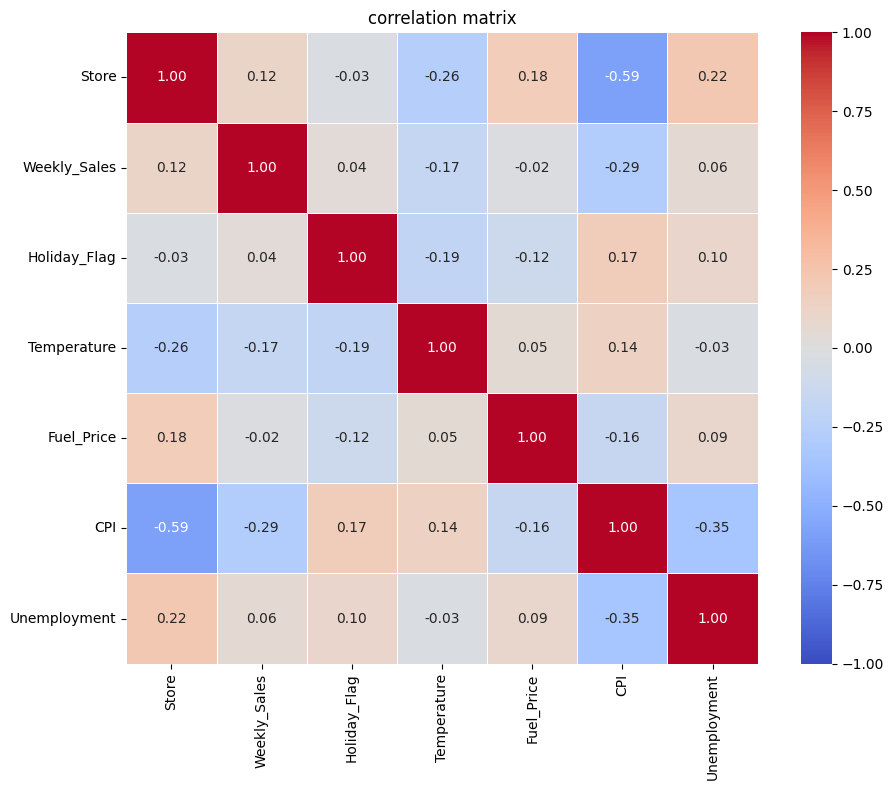

In [4]:
# Let’s look at the correlation between the variables 
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True), # to avoid any issues with the Date column
    annot=True,
    fmt='.2f', # 2 decimal places 
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("correlation matrix")
plt.tight_layout()
plt.show()

The variables appear to be weakly correlated. We wondered whether CPI and unemployment might be collinear, yet they have a correlation of -35%. This means there is a slight negative correlation between the two: a fall in unemployment coincides maybe with rising prices. They are not strongly correlated, but we will need to monitor whether this really has no impact on the model. 

The only variables that appear to be slightly correlated are unemployment and Fuel_Price with Store. However, Store is a sequence of arbitrary numbers; the algorithm must, for example, have found that high Store figures correspond weakly with a high rate of unemployment, but this simply does not make sense. There is therefore no collinearity between these variables. 

### 1.2.2. Outliers 

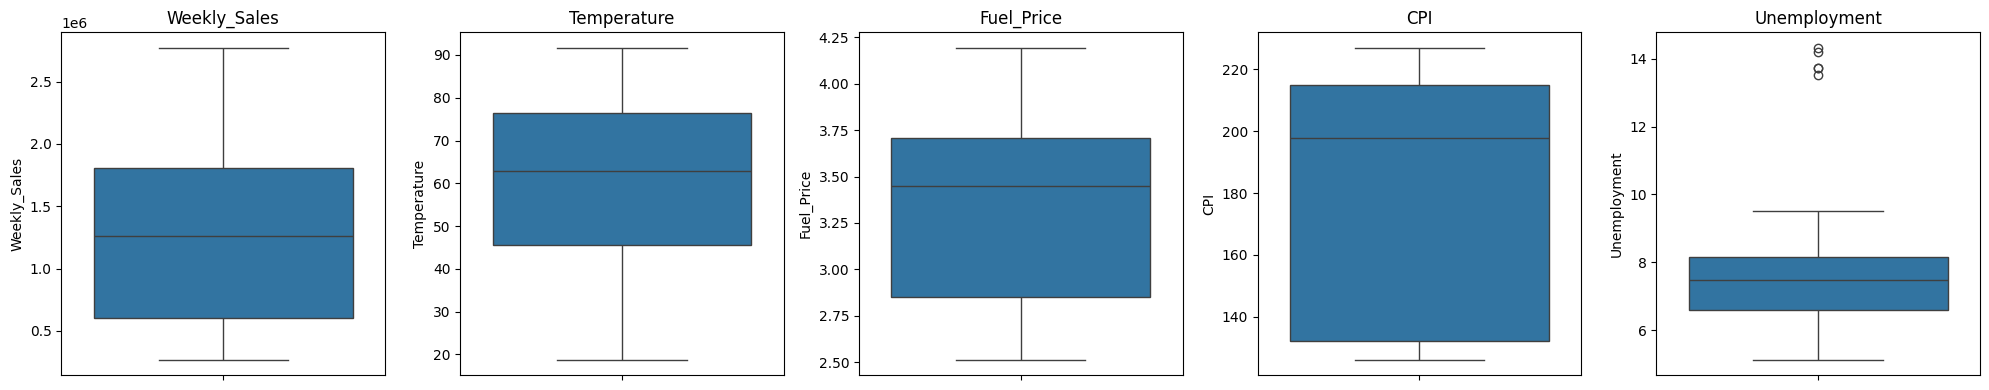

In [5]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

The dataset contains few outliers. Only the ‘Unemployment’ category appears to be affected. 
The CPI column seems to have a very wide distribution. Let’s take a closer look at this 

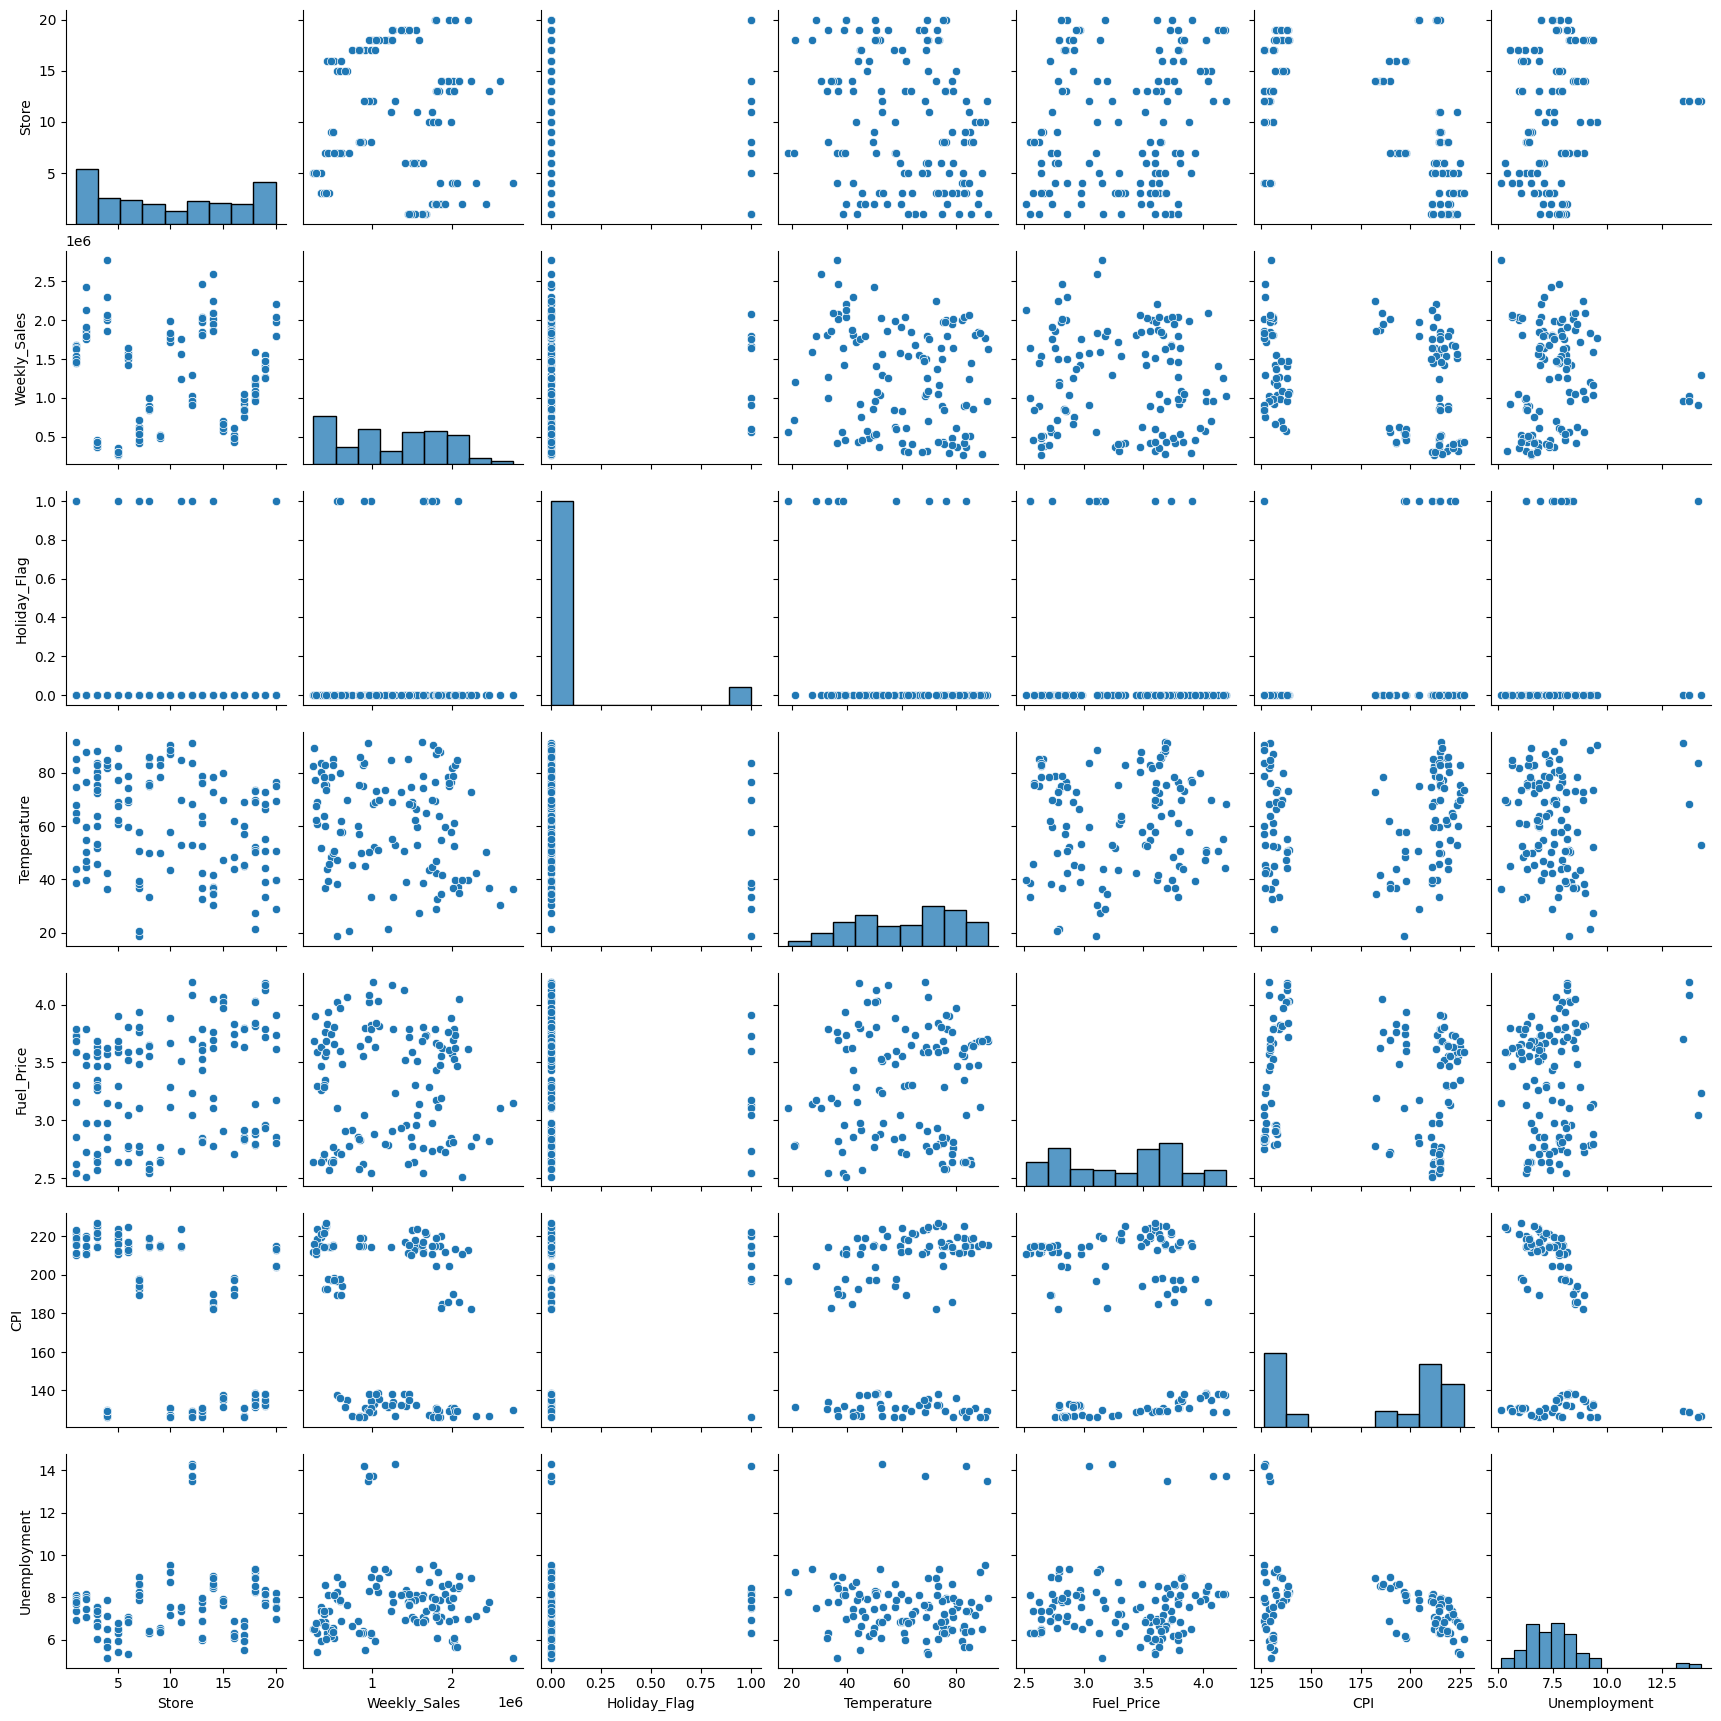

In [6]:
sns.pairplot(df)

The distribution of CPI is very clear: values tend either towards the minimum or towards the maximum. This suggests that there are likely two types of shops: those in urban areas with high prices, and those outside towns with lower prices. For a linear regression model, creating a new variable using these parameters simply introduces multicollinearity and is therefore not useful. 

### 1.2.3. Missing values

Let’s look at the proportion of missing values 

In [7]:
missing_values = df.isna().sum() / df.shape[0] * 100
print("The percentage of missing values for each variable:")
display(missing_values)

The percentage of missing values for each variable:


Store            0.000000
Date            12.000000
Weekly_Sales     9.333333
Holiday_Flag     8.000000
Temperature     12.000000
Fuel_Price       9.333333
CPI              8.000000
Unemployment    10.000000
dtype: float64

In [8]:
df = df.dropna(subset=["Weekly_Sales"])

# We check and see what has changed in the other variables 
missing_values = df.isna().sum() / df.shape[0] * 100
print("The percentage of missing values for each variable is now:")
display(missing_values)

The percentage of missing values for each variable is now:


Store            0.000000
Date            13.235294
Weekly_Sales     0.000000
Holiday_Flag     8.088235
Temperature     11.029412
Fuel_Price       8.823529
CPI              8.088235
Unemployment    10.294118
dtype: float64

There are no missing values in the target variable. We can therefore move on to separating the X and Y variables, setting up the training and testing sets, and preprocessing. 

# 2. Data preparation 

Before beginning data preparation, we need to determine what type of model to use.      

We have tabular data with a continuous numerical target. Linear regression is therefore the most direct mathematical approach.      
Walmart also wants the development of this model to help them understand the different importances of the variables. Linear regression will allow us to fully understand its parameters.

## 2.1. Date conversion 

First of all, we need to convert the date column, which is currently a string 

In [9]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce") # forces the conversion and sets NaT if it fails 
display(df["Date"]) 

print("Number of missing values:")  
display(df["Date"].isna().sum())  

C:\Users\axelv\AppData\Local\Temp\ipykernel_56040\2434791523.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce") # forces the conversion and sets NaT if it fails


0     2011-02-18
1     2011-03-25
3            NaT
4     2010-05-28
5     2010-05-28
         ...    
145   2010-06-18
146          NaT
147   2010-06-11
148   2011-08-12
149   2012-04-20
Name: Date, Length: 136, dtype: datetime64[ns]

Number of missing values:


18

So there are 18 missing values in the dates. Given the limited number of rows in the dataset, we should try to retain as many of them as possible.          
If there is a certain degree of linearity in the dates, we might be able to replace them with a value that won’t be an outlier. Let’s see if this pattern is indeed present.        

In [10]:
# We sort by shop and look at the differences between the dates 
display(df.sort_values('Date').groupby('Store')['Date'].diff().value_counts())

print("Reminder of the number of rows in the dataset:", df.shape[0])

Date
105 days    7
119 days    6
14 days     6
77 days     5
70 days     5
42 days     5
168 days    4
28 days     4
56 days     4
63 days     3
91 days     3
49 days     3
7 days      3
112 days    3
21 days     3
315 days    3
98 days     3
343 days    2
140 days    2
126 days    2
196 days    2
462 days    1
616 days    1
378 days    1
210 days    1
35 days     1
399 days    1
700 days    1
147 days    1
287 days    1
182 days    1
329 days    1
469 days    1
273 days    1
406 days    1
238 days    1
203 days    1
175 days    1
133 days    1
266 days    1
217 days    1
Name: count, dtype: int64

Reminder of the number of rows in the dataset: 136


The discrepancies are not consistent, so it is not possible to replace the dates with a reliable approximate date.              
We currently have 136 rows in our dataset, which is very few. In this case, deleting 18 rows represents a very large proportion.            
Let’s consider the relevance of the ‘date’ variable in relation to the others. ‘Date’ could be useful for analysing seasonality or days off work. However, we have a dataset that includes holiday dates and temperature. We therefore do not need the ‘date’ column, it is better to delete it. 

In [11]:
df = df.drop(["Date"], axis=1)

In [12]:
display(df)
print(df.dtypes)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470
3,11.0,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092
5,4.0,1857533.70,0.0,NaN,2.756,126.160226,7.896
...,...,...,...,...,...,...,...
145,14.0,2248645.59,0.0,72.62,2.780,182.442420,8.899
146,7.0,716388.81,NaN,20.74,2.778,NaN,NaN
147,17.0,845252.21,0.0,57.14,2.841,126.111903,NaN
148,8.0,856796.10,0.0,86.05,3.638,219.007525,NaN


Store           float64
Weekly_Sales    float64
Holiday_Flag    float64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


## 2.2. Separation of X et y and train/test split
We will now isolate X and y

In [13]:
target = "Weekly_Sales"

y = df.loc[:, target]
print("y contains:", target)

X = df.drop(target, axis=1)
print("X contains:", X.columns.tolist())

y contains: Weekly_Sales
X contains: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


In [14]:
print("Dividing into train and test sets...")
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Done")

Dividing into train and test sets...
Done


## 2.3. Preprocessing

We cannot train a model with missing values, so we will first impute them.      

We then want to train a linear regression model. This means we also need to standardise all the data. This is necessary so that we can compare the results with one another later on. It also allows us to use Ridge and Lasso, as their regularization penalties are applied fairly across features only when those are on the same scale.


In [15]:
display(X_train.describe())

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,108.000000,100.000000,96.000000,96.000000,99.000000,97.000000
mean,10.277778,0.070000,60.884063,3.344906,178.603623,7.611845
std,6.101683,0.256432,18.119041,0.494162,40.122425,1.640513
min,1.000000,0.000000,18.790000,2.514000,126.111903,5.422000
25%,4.750000,0.000000,44.787500,2.853750,132.078532,6.664000
50%,10.500000,0.000000,62.310000,3.489500,196.919506,7.368000
75%,15.250000,0.000000,76.047500,3.752500,214.726005,8.150000
max,20.000000,1.000000,90.320000,4.193000,226.968844,14.313000


Before doing that, let’s take a closer look at the Unemployment variable. The box plot had shown outliers above 12 

In [16]:
df[df["Unemployment"] > 12]

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
30,12.0,1021154.48,0.0,68.40,4.193,129.044433,13.736
62,12.0,1295605.35,0.0,52.77,3.236,126.879484,14.313
68,12.0,955913.68,0.0,91.04,3.701,129.201581,13.503
93,12.0,964332.51,0.0,NaN,4.087,129.062355,13.736
135,12.0,903119.03,1.0,83.63,3.044,126.114581,14.180


All the outliers for unemployment are located in the same branch. Store 12 therefore appears to be situated in an area with a higher unemployment rate. These outliers are not, in fact, due to chance, but rather to a specific characteristic of this branch, they should therefore be retained. 

Right then, although all our X columns are floats, there is still a difference between the columns: Holiday_Flag is actually a boolean. We therefore need to treat it separately.       

What about the Store variable?      
It could be regarded either as an identifier to be removed or as an important variable. Indeed, CPI tells us that we have two types of stores: one in an environment where the average basket value is high, and the other in the opposite environment. The variable Store may therefore be redundant. Given that we are working with a baseline here, I will remove this column for the time being. This will allow us to assess its level of importance. 

Let’s build a pipeline that takes these specifics into account    

Which strategy should we use with SimplImputer: mean or median?         
In addition to the pseudo-outliers in Unemployment, we have seen that CPI values are at opposite ends of the spectrum, no doubt due to the location of the shops. If we apply the mean to this data, we will create values that lie in the middle and are not surrounded by any real values. This would be tantamount to creating a new category of shop that does not exist. We will therefore choose the median so that it falls within one of the clusters occupied by the real data. 
As for the Boolean class, you should therefore select ‘most frequent’ to ensure that only Booleans are included 

In [17]:
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
binary_features = ["Holiday_Flag"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) 
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features)
])
print("Preprocessing pipeline initialized.")
display(preprocessor)

print("Fitting preprocessor on X_train...")
X_train_processed = preprocessor.fit_transform(X_train)
print("...Done")
print(X_train_processed[0:5, :])

print("Transforming X_test...")
X_test_processed = preprocessor.transform(X_test)
print("...Done")
print(X_test_processed[0:5, :])

Preprocessing pipeline initialized.


,transformers,"[('numeric', ...), ('binary', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Fitting preprocessor on X_train...
...Done
[[-1.43724832  0.8718845   0.32931107  0.65096865  0.        ]
 [ 0.40751203  0.50039263  1.12300261 -0.14143797  0.        ]
 [ 1.02870685 -1.40860316  0.89137992 -0.15758317  0.        ]
 [ 1.11341523  1.31209162 -1.14791163  0.14142601  0.        ]
 [ 0.07456103 -1.49020253  0.89674716 -0.14143797  0.        ]]
Transforming X_test...
...Done
[[-0.65193102 -1.26687794  0.91579911 -0.66325097  0.        ]
 [ 1.80049435  0.69365429  0.91858309  0.24217208  0.        ]
 [-1.44724862 -0.45517894 -1.30291081 -1.57836114  0.        ]
 [-0.37721702  0.41664591  1.04130387 -0.34228431  0.        ]
 [ 0.8528193  -0.16313909  0.43548632 -0.25187116  0.        ]]


## 2.4. Training

We can now train our model on this data 

In [18]:
print("Initializing the model...")
regressor = LinearRegression()
print("...Done")

print("Training the model on X_train and y_train...")
regressor.fit(X_train_processed, y_train)
print("...Done")

Initializing the model...
...Done
Training the model on X_train and y_train...
...Done


In [19]:
y_pred_train = regressor.predict(X_train_processed)
y_pred_test = regressor.predict(X_test_processed)

print("Training set: ")
print(f"R²    : {r2_score(y_train, y_pred_train):.3f}")
print(f"MAE   : {mean_absolute_error(y_train, y_pred_train):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train, y_pred_train)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train, y_pred_train):.1%}")

print("Test set: ")
print(f"R²    : {r2_score(y_test, y_pred_test):.3f}")
print(f"MAE   : {mean_absolute_error(y_test, y_pred_test):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test, y_pred_test):.1%}")

Training set: 
R²    : 0.125
MAE   : 538,090 $
RMSE  : 598,440 $
MAPE  : 68.1%
Test set: 
R²    : -0.130
MAE   : 666,403 $
RMSE  : 707,343 $
MAPE  : 78.1%


Here, our baseline model is completely ineffective.         

We have a negative R² value.            
R² is the coefficient of determination; it measures the dispersion of values around their mean. This means that here it assesses whether the model can explain price variations: are they due to the season, the holidays, or the shop? For the moment, the model has completely failed to grasp this principle. We recall that we removed the date and Store variables. We will see if reintroducing them can have a positive impact.      

The MAE is $666.403            
This measures the mean absolute error, in the same unit as the target. Here, it indicates that the model is therefore off by $666.403 compared to what the estimated prices should be. That is more than half of a day’s profits so it is therefore not usable in production.     

The RMSE is $707.343       
The mechanism is similar to that of the MAE, but the calculation uses the squares of the actual and predicted values. This means that this metric is more sensitive to large errors. If the RMSE is higher than the MAE, which is the case here, it means that the errors are homogeneous. The model is wrong, but at least it is consistently wrong. This means that some fundamental variables are missing.

The MAPE is 78%.            
MAPE indicates the average error as a percentage of the actual value. On average, our model is therefore 78% off the actual value. This helps us understand that the errors in dollars we previously had are indeed significant. 

# 3. Version 01
## 3.1. Reintroducing the Store variable

Our metrics show us that we are missing a key variable. We have removed the location variable (Store) and the time variable (Date).
We will take this opportunity to assess the importance of these variables. We will reintroduce them one by one and check their impact on our metrics each time. 

In [20]:
df_v1 = pd.read_csv(r"Walmart_Store_sales.csv")
df_v1 = df_v1.dropna(subset=["Weekly_Sales"]) 
print("Dataset loaded, target cleaned")

# We remove the date only 
df_v1 = df_v1.drop(columns=["Date"])
print("Date column removed")

print("Separation of X and y")
target = "Weekly_Sales"
y_v1 = df_v1.loc[:, target]
print("y contains:", target)
X_v1 = df_v1.drop(target, axis=1)
print("X contains:", X.columns.tolist())

X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.2, random_state=42
)
print("train/test split done")

Dataset loaded, target cleaned
Date column removed
Separation of X and y
y contains: Weekly_Sales
X contains: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
train/test split done


## 3.2. What pre-processing is required for Store? 

What preprocessing should be applied to Store?          
We will treat Store as a categorical variable. Why? Because it semantically represents a category: shops. If we treated it as numerical, this would imply that the associated number had meaning. Consequently, shop ‘12’ might be perceived by the model as larger or more significant than shop ‘3’. We want to avoid this error.         
As this variable is categorical, we will therefore use `most_frequency` in SimpleImputer so that, instead of returning NaNs, it returns a shop that actually exists. 

In [21]:
numeric_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
binary_features = ["Holiday_Flag"]
categorical_features = ["Store"]

# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor_v1 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline initialized.")
display(preprocessor_v1)
X_train_v1_processed = preprocessor_v1.fit_transform(X_train_v1)
X_test_v1_processed = preprocessor_v1.transform(X_test_v1)

regressor_v1 = LinearRegression()

print("Training the model on X_train and y_train...")
regressor_v1.fit(X_train_v1_processed, y_train_v1)
print("Done")

y_pred_train_v1 = regressor_v1.predict(X_train_v1_processed)
y_pred_test_v1 = regressor_v1.predict(X_test_v1_processed)

print("V1 - Training set:")
print(f"R²    : {r2_score(y_train_v1, y_pred_train_v1):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v1, y_pred_train_v1):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v1, y_pred_train_v1)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v1, y_pred_train_v1):.1%}")

print("\nV1 - Test set:")
print(f"R²    : {r2_score(y_test_v1, y_pred_test_v1):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v1, y_pred_test_v1):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v1, y_pred_test_v1)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v1, y_pred_test_v1):.1%}")

Preprocessing pipeline initialized.


,transformers,"[('numeric', ...), ('binary', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Training the model on X_train and y_train...
Done
V1 - Training set:
R²    : 0.970
MAE   : 79,135 $
RMSE  : 111,087 $
MAPE  : 6.5%

V1 - Test set:
R²    : 0.916
MAE   : 140,327 $
RMSE  : 192,635 $
MAPE  : 11.9%


### 3.3. Conclusion of Version 01

Store was indeed a key variable in this dataset. This therefore confirms what we saw with CPI: there are two categories of Walmart: One in an area where the average shopping bill is high, the other in an area where the average shopping bill is low. Perhaps a comparison between urban and rural shops, or perhaps two different regions.

The R² of 0.916 indicates that the model explains 92% of the variance in weekly sales. As for the error in the predicted prices, we have a model that is, on average, 12% off the mark compared to the actual values. 
The R² of the training set is 5% off, so we have very slight overfitting. 

These results are much better; no fundamental variables are missing. Out of curiosity, let’s see what happens when we add the date variable. 




# 4. Version 02 
## 4.1. Reintroducing the Store variable

In [22]:
# 4.1. Data preparation with Date
df_v2 = pd.read_csv(r"Walmart_Store_sales.csv")
df_v2 = df_v2.dropna(subset=["Weekly_Sales"])
print(f"After dropping NaN on target: {df_v2.shape[0]} rows")

# Date conversion and removal of rows containing NaN values
df_v2["Date"] = pd.to_datetime(df_v2["Date"], format="%d-%m-%Y", errors="coerce")
df_v2 = df_v2.dropna(subset=["Date"])
print("Number of lines after the NaN drop:", len(df_v2))

After dropping NaN on target: 136 rows
Number of lines after the NaN drop: 118


In [23]:
# Extract date components
df_v2["year"] = df_v2["Date"].dt.year
df_v2["month"] = df_v2["Date"].dt.month
df_v2["day"] = df_v2["Date"].dt.day
df_v2["dayofweek"] = df_v2["Date"].dt.dayofweek

## 4.2. How should time variables be treated? 

If we treat time as a non-categorical variable, we run several risks: 
- The influence of time on Walmart’s sales is not linear. The peak in sales in December bears no relation to sales in September, which are themselves very different from sales during the summer. We are dealing with a cyclical pattern and therefore a non-linear one. 
- Numerically, December and January are opposites, which is incorrect. 

However, if we treat time as a categorical variable, we will have to use OneHotEncoder, which will significantly increase the number of columns. This is not ideal for a model of our type 

We want to preserve the cyclical nature of how weather influences sales. We will therefore use the principle of cyclical encoding, as described in this article: 
[Cyclical Encoding](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/)     

The principle is as follows: We retain this numerical variable, but we use a calculation involving sine and cosine to convert it into cyclic data. We will then have two columns: cosine and sine. So, midnight will be next to 23 and 1 a.m., and December next to January  

In [24]:
# Cyclical encoding
df_v2["month_sin"] = np.sin(2 * np.pi * df_v2["month"] / 12)
df_v2["month_cos"] = np.cos(2 * np.pi * df_v2["month"] / 12)

df_v2["dayofweek_sin"] = np.sin(2 * np.pi * df_v2["dayofweek"] / 7)
df_v2["dayofweek_cos"] = np.cos(2 * np.pi * df_v2["dayofweek"] / 7)

df_v2["day_sin"] = np.sin(2 * np.pi * df_v2["day"] / 31)
df_v2["day_cos"] = np.cos(2 * np.pi * df_v2["day"] / 31)
# We are leaving ‘year’ as it is, as the years are not cyclical

In [25]:
df_v2 = df_v2.drop(columns=["Date", "month", "day", "dayofweek"])

# X/y split
target = "Weekly_Sales"
y_v2 = df_v2[target]
X_v2 = df_v2.drop(columns=[target])

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

In [26]:
# Preprocessing
numeric_features = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'year',
    'month_sin', 'month_cos',
    'dayofweek_sin', 'dayofweek_cos',
    'day_sin', 'day_cos'
]
binary_features = ["Holiday_Flag"]
categorical_features = ["Store"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor_v2 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

X_train_v2_processed = preprocessor_v2.fit_transform(X_train_v2)
X_test_v2_processed = preprocessor_v2.transform(X_test_v2)

c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [27]:
# Training
regressor_v2 = LinearRegression()
print("Training the model on X_train and y_train...")
regressor_v2.fit(X_train_v2_processed, y_train_v2)
print("Done")

# Prediction
y_pred_train_v2 = regressor_v2.predict(X_train_v2_processed)
y_pred_test_v2 = regressor_v2.predict(X_test_v2_processed)

# 4.5. Evaluation
print("\nV2 - Training set:")
print(f"R²    : {r2_score(y_train_v2, y_pred_train_v2):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v2, y_pred_train_v2):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v2)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v2, y_pred_train_v2):.1%}")

print("\nV2 - Test set:")
print(f"R²    : {r2_score(y_test_v2, y_pred_test_v2):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_test_v2):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v2)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v2, y_pred_test_v2):.1%}")

Training the model on X_train and y_train...
Done

V2 - Training set:
R²    : 0.966
MAE   : 92,908 $
RMSE  : 124,942 $
MAPE  : 8.9%

V2 - Test set:
R²    : 0.927
MAE   : 136,952 $
RMSE  : 159,616 $
MAPE  : 15.6%


## 4.3. Conclusion of Version 02 and coefficients analysis

The model has improved.         

The R² has increased by 0.011, meaning the model is now better able to capture the variations in the data. 

The MAE has decreased by 3.375, which is a significant improvement.    

The RMSE, meanwhile, has fallen by 33.019, which is a marked difference. This means that the data allows for a better understanding of extreme values. This may correspond, for example, to the Christmas period, which the model has managed to capture more accurately.

It should be noted that this comparison of metrics is limited by the fact that rows were also removed from the dataset between the models.

Let’s take a quick look at the odds we’ve got 

In [28]:
print(pd.Series(regressor_v2.coef_, 
                index=preprocessor_v2.get_feature_names_out())
                .sort_values(key=abs, ascending=False)
)


categorical__Store_5.0    -1.342595e+06
categorical__Store_3.0    -1.199367e+06
categorical__Store_9.0    -1.181723e+06
categorical__Store_16.0   -1.062079e+06
categorical__Store_7.0    -8.933251e+05
categorical__Store_15.0   -7.987061e+05
categorical__Store_8.0    -7.829328e+05
categorical__Store_4.0     7.472149e+05
categorical__Store_10.0    6.989661e+05
categorical__Store_14.0    6.783107e+05
categorical__Store_17.0   -6.451233e+05
categorical__Store_13.0    6.294103e+05
categorical__Store_20.0    4.388294e+05
categorical__Store_2.0     3.532493e+05
categorical__Store_12.0    2.661442e+05
categorical__Store_19.0    1.565068e+05
categorical__Store_18.0   -1.536351e+05
binary__Holiday_Flag      -1.443647e+05
numeric__Unemployment     -1.322415e+05
numeric__CPI               9.965081e+04
numeric__Fuel_Price       -4.143154e+04
numeric__year             -3.784194e+04
numeric__Temperature      -3.519122e+04
numeric__day_cos          -3.445189e+04
numeric__month_cos         2.086198e+04


We can see the fundamental importance of the various stores. They vary widely, ranging from -1.342595e+06 to 7.472149e+05. This means that each has its own specific characteristics and circumstances. 

Next, curiously, we see a negative value for the Holiday_flag at -1.443647e+05. This is surprising because one would intuitively expect holidays to have a positive impact on sales. Perhaps some shops close during the holidays. We will need to look at this variable more closely. 

Unemployment has a negative impact on sales, which is to be expected. Conversely, a high CPI drives up total sales, which is also to be expected. Fuel has a negative impact, meaning that when its price rises, sales fall. 

Temperature has a negative impact of -3.519122e+04. This is an opportunity to examine the consistency of this data within the context of our linear regression. One might imagine that very cold or very hot temperatures reduce people’s motivation to go out. In this case, it is therefore the average, moderate temperatures that encourage people to go out. 
However, our linear regression can only follow a straight line; it cannot take on the bell-shaped curve that this would imply. We will also look at this variable in more detail later to see how to resolve this issue. 

Finally, the time variables relating to the days have a negative correlation of -2.415618e-09 and -9.313226e-10. We already have the day variables in cosine and sine. Dayofweek is probably redundant, we can remove it. 

# 5. Version 03 : Removing the day of week variable

So we have three things to do:
- Analyse the unusual nature of the Holiday_flag variable

- Transform the temperature variable so that the linear regression can capture its peculiarity, which may be an inverted U-shape
  
- Remove the day of week variable
  
For the time being, we will remove the noise that may be caused by the day of the week 

In [29]:
# We use the same pipeline as V2
numeric_features = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'year',
    'month_sin', 'month_cos',
    'day_sin', 'day_cos'
]
binary_features = ["Holiday_Flag"]
categorical_features = ["Store"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# New preprocessor for V3
preprocessor_v3 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit et transform using v2 input data
X_train_v3_processed = preprocessor_v3.fit_transform(X_train_v2)
X_test_v3_processed = preprocessor_v3.transform(X_test_v2)
print(f"Shape after preprocessing — train: {X_train_v3_processed.shape}, test: {X_test_v3_processed.shape}")

# Training
regressor_v3 = LinearRegression()
print("Training the model on X_train_v3_processed and y_train_v2...")
regressor_v3.fit(X_train_v3_processed, y_train_v2)
print("Done")

# Prediction
y_pred_train_v3 = regressor_v3.predict(X_train_v3_processed)
y_pred_test_v3 = regressor_v3.predict(X_test_v3_processed)

# Evaluation
print("\nV3 - Training set:")
print(f"R²    : {r2_score(y_train_v2, y_pred_train_v3):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v2, y_pred_train_v3):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v3)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v2, y_pred_train_v3):.1%}")

print("\nV3 - Test set:")
print(f"R²    : {r2_score(y_test_v2, y_pred_test_v3):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_test_v3):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v3)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v2, y_pred_test_v3):.1%}")

Shape after preprocessing — train: (94, 28), test: (24, 28)
Training the model on X_train_v3_processed and y_train_v2...
Done

V3 - Training set:
R²    : 0.966
MAE   : 92,908 $
RMSE  : 124,942 $
MAPE  : 8.9%

V3 - Test set:
R²    : 0.927
MAE   : 136,952 $
RMSE  : 159,616 $
MAPE  : 15.6%


c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


The results are exactly the same, which confirms that `dayofweek` was indeed just unnecessary noise 

## 6. Version 04 : feature engineering on temperature

Here’s the problem: it is entirely possible that the optimal temperature for influencing sales is when it is neither too cold nor too hot. The temperature variable would therefore have an impact on sales in the shape of an inverted U. 

However, our model is a linear regression, which cannot directly capture this shape. 

We therefore need to transform the temperature variable to try to capture these parameters. We will create binary variables: ‘too cold’ and ‘too hot’, leaving a range for moderate temperatures. 

In [30]:
# Let’s take a closer look at our temperatures 
df["Temperature"].describe()

count    121.000000
mean      60.853967
std       18.514432
min       18.790000
25%       45.220000
50%       62.250000
75%       75.950000
max       91.650000
Name: Temperature, dtype: float64

Temperatures range from 18 to 91 degrees Fahrenheit, which is equivalent to -7 and 33 degrees Celsius.      
These aren’t truly extreme temperatures. Our reasoning might not hold water, but let’s take a look at the impact of this feature engineering anyway.

Which range should we choose?     

If we use quartiles, we capture the summer and winter seasons. If we use more extreme temperature ranges, we capture the extremes but place the majority of our dataset in the temperate range.     

When can temperature really impact purchases?       
Either we assume that people change their habits according to the seasons, or we assume that they change their habits when the temperature is unusual. Here, we will focus on extreme temperatures. 

In [31]:
df_v2["cold"] = df_v2["Temperature"] <= 39 
df_v2["hot"] = df_v2["Temperature"] >= 84

X_v4 = df_v2.drop(columns=[target])
y_v4 = df_v2[target]

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42
)

numeric_features = [
    "Fuel_Price", "CPI", "Unemployment",
    "year",
    "month_sin", "month_cos",
    "day_sin", "day_cos"
]

binary_features = ["Holiday_Flag", "hot", "cold"]
categorical_features = ["Store"]

In [32]:
# Same pipeline 
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# New preprocessor for V3
preprocessor_v4 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit et transform using v2 input data
X_train_v4_processed = preprocessor_v4.fit_transform(X_train_v4)
X_test_v4_processed = preprocessor_v4.transform(X_test_v4)
print(f"Shape after preprocessing — train: {X_train_v4_processed.shape}, test: {X_test_v4_processed.shape}")

# Training
regressor_v4 = LinearRegression()
print("Training the model on X_train_v4_processed")
regressor_v4.fit(X_train_v4_processed, y_train_v4)
print("Done")

# Prediction
y_pred_train_v4 = regressor_v4.predict(X_train_v4_processed)
y_pred_test_v4 = regressor_v4.predict(X_test_v4_processed)

# Evaluation
print("\nV3 - Training set:")
print(f"R²    : {r2_score(y_train_v4, y_pred_train_v4):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v4, y_pred_train_v4):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v4, y_pred_train_v4)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v4, y_pred_train_v4):.1%}")

print("\nV3 - Test set:")
print(f"R²    : {r2_score(y_test_v4, y_pred_test_v4):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v4, y_pred_test_v4):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v4, y_pred_test_v4)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v4, y_pred_test_v4):.1%}")

Shape after preprocessing — train: (94, 29), test: (24, 29)
Training the model on X_train_v4_processed
Done

V3 - Training set:
R²    : 0.967
MAE   : 89,240 $
RMSE  : 122,994 $
MAPE  : 8.3%

V3 - Test set:
R²    : 0.919
MAE   : 140,157 $
RMSE  : 168,249 $
MAPE  : 16.1%


c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


The metrics have dropped. The temperatures weren't that extreme, so there's no point in forcing the model to make predictions based on whether they are very low or very high 

# 7. Version 05 : analysing the Holiday_flag variable

Holiday_flag shows a counterintuitive correlation: it is negative, even though one would expect a festive period to boost sales. This may be because customers are doing their shopping in advance, or because shops close during these periods. We will take a closer look at t

In [33]:
print(df_v2.groupby("Holiday_Flag")["Weekly_Sales"].mean())

Holiday_Flag
0.0    1.250538e+06
1.0    1.291931e+06
Name: Weekly_Sales, dtype: float64


We can see that the averages for public holidays and other days are very similar. The model may already account for periods of increased spending simply through the time columns. We will therefore remove this variable and see what happens. 

In [34]:
numeric_features = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'year',
    'month_sin', 'month_cos',
    'day_sin', 'day_cos'
]

categorical_features = ["Store"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Removal of the pipeline relating to Holiday_flag

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# New preprocessor for V5
preprocessor_v5 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit et transform using v2 input data
X_train_v5_processed = preprocessor_v5.fit_transform(X_train_v2)
X_test_v5_processed = preprocessor_v5.transform(X_test_v2)
print(f"Shape after preprocessing — train: {X_train_v5_processed.shape}, test: {X_test_v5_processed.shape}")

# Training
regressor_v5 = LinearRegression()
print("Training the model on X_train_v5_processed and y_train_v2...")
regressor_v5.fit(X_train_v5_processed, y_train_v2)
print("Done")

# Prediction
y_pred_train_v5 = regressor_v5.predict(X_train_v5_processed)
y_pred_test_v5 = regressor_v5.predict(X_test_v5_processed)

# Evaluation
print("\nV5 - Training set:")
print(f"R²    : {r2_score(y_train_v2, y_pred_train_v5):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v2, y_pred_train_v5):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v5)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v2, y_pred_train_v5):.1%}")

print("\nV5 - Test set:")
print(f"R²    : {r2_score(y_test_v2, y_pred_test_v5):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_test_v5):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v5)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v2, y_pred_test_v5):.1%}")

c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Shape after preprocessing — train: (94, 27), test: (24, 27)
Training the model on X_train_v5_processed and y_train_v2...
Done

V5 - Training set:
R²    : 0.964
MAE   : 94,288 $
RMSE  : 127,597 $
MAPE  : 8.7%

V5 - Test set:
R²    : 0.943
MAE   : 122,009 $
RMSE  : 140,778 $
MAPE  : 13.4%


The model has indeed improved significantly.        
The R² has increased by 0.016. Most notably, the RMSE has fallen more sharply (-$18,838) than the MAE (-$14,943). This means it is making fewer major errors. The Holiday_flag was therefore introducing noise that was causing significant errors in our model 

# 8. Version 06: Ridge and cross-validation
## 8.1. First attempt with Ridge 

At this stage, we therefore have variables that are undoubtedly all necessary. We will therefore add a regularisation method to enable our model to produce more nuanced predictions. 

We therefore have the choice between Ridge and Lasso. 
The strength of Lasso lies in pruning the variables by allowing their weights to be reduced to zero. Here, we have chosen our variables and believe that they are now all necessary. We therefore want to keep them all and adjust their weights, which is why we will use Ridge. 

We have observed that certain variables, such as ‘Stores’, had extreme coefficients such as 7.472149e+05. Furthermore, some necessary variables may be slightly correlated with one another, such as CPI and the unemployment rate. Ridge will help to smooth out the coefficients and manage potential multicollinearity. 

Ridge requires alpha parameters to be specified in order to work, so we will use cross-validation to select the correct value for alpha 

In [35]:
# We use the same pipeline as V5
numeric_features = [
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'year',
    'month_sin', 'month_cos',
    'day_sin', 'day_cos'
]

categorical_features = ["Store"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Removal of the pipeline relating to Holiday_flag

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# New preprocessor for V5
preprocessor_v6 = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit et transform 
X_train_v6_processed = preprocessor_v6.fit_transform(X_train_v2)
X_test_v6_processed = preprocessor_v6.transform(X_test_v2)
print(f"Shape after preprocessing — train: {X_train_v5_processed.shape}, test: {X_test_v5_processed.shape}")


Shape after preprocessing — train: (94, 27), test: (24, 27)


c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Implementation of Ridge and cross-validation 

In [36]:
# Training
regressor_v6 = Ridge()
print("Training the model with Ridge")
params = {"alpha" : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0] }

gridsearch = GridSearchCV(regressor_v6, param_grid=params, cv=5)

print("Searching for the optimal setting")
gridsearch.fit(X_train_v6_processed, y_train_v2)
print("Done")

# Displaying the best settings
print(f"\nLe meilleur paramètre trouvé est : {gridsearch.best_params_}")

# Automatic selection of the best template
best_v6 = gridsearch.best_estimator_

# Predictions using the optimised model
y_pred_train_v6 = best_v6.predict(X_train_v6_processed)
y_pred_test_v6 = best_v6.predict(X_test_v6_processed)

# Assessment
print("\nV6 (v6) - Training set:")
print(f"R²    : {r2_score(y_train_v2, y_pred_train_v6):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v2, y_pred_train_v6):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v6)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v2, y_pred_train_v6):.1%}")

print("\nV6 (v6) - Test set:")
print(f"R²    : {r2_score(y_test_v2, y_pred_test_v6):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_test_v6):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v6)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v2, y_pred_test_v6):.1%}")

Training the model with Ridge
Searching for the optimal setting
Done

Le meilleur paramètre trouvé est : {'alpha': 0.01}

V6 (v6) - Training set:
R²    : 0.964
MAE   : 94,106 $
RMSE  : 127,642 $
MAPE  : 8.7%

V6 (v6) - Test set:
R²    : 0.944
MAE   : 120,374 $
RMSE  : 139,494 $
MAPE  : 13.1%


## 8.2. Second attempt with Ridge 

Now let’s see if we can make this grisearchCv a bit more refined. The best parameter of 0.01 gave us the order of magnitude, so we’ll look around that value.

In [37]:
# Training
regressor_v6 = Ridge()
print("Training the model with Ridge")
params = {"alpha" : [0.001, 0.005, 0.008, 0.01, 0.012, 0.013, 0.014, 0.015, 0.02, 0.05] }

gridsearch = GridSearchCV(regressor_v6, param_grid=params, cv=5)

print("Searching for the optimal setting")
gridsearch.fit(X_train_v6_processed, y_train_v2)
print("Done")

# Displaying the best settings
print(f"\nBest params : {gridsearch.best_params_}")

# Automatic selection of the best template
best_v6 = gridsearch.best_estimator_

# Predictions using the optimised model
y_pred_train_v6 = best_v6.predict(X_train_v6_processed)
y_pred_test_v6 = best_v6.predict(X_test_v6_processed)

# Assessment
print("\nV6 (v6) - Training set:")
print(f"R²    : {r2_score(y_train_v2, y_pred_train_v6):.3f}")
print(f"MAE   : {mean_absolute_error(y_train_v2, y_pred_train_v6):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v6)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_train_v2, y_pred_train_v6):.1%}")

print("\nV6 (v6) - Test set:")
print(f"R²    : {r2_score(y_test_v2, y_pred_test_v6):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_test_v6):,.0f} $")
print(f"RMSE  : {np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v6)):,.0f} $")
print(f"MAPE  : {mean_absolute_percentage_error(y_test_v2, y_pred_test_v6):.1%}")

Training the model with Ridge
Searching for the optimal setting
Done

Best params : {'alpha': 0.013}

V6 (v6) - Training set:
R²    : 0.964
MAE   : 94,067 $
RMSE  : 127,671 $
MAPE  : 8.7%

V6 (v6) - Test set:
R²    : 0.944
MAE   : 119,899 $
RMSE  : 139,172 $
MAPE  : 12.9%


and we save the model

In [38]:
# Saving the model
# pipeline to automatically apply transformations to new data
final_pipeline = Pipeline([
    ("preprocessor", preprocessor_v6),
    ("regressor", best_v6)
])

# Retrains the pipeline on the training data
final_pipeline.fit(X_train_v2, y_train_v2)

# Save in the models folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)
model_path = models_dir / "walmart_sales_model_v6.joblib"
joblib.dump(final_pipeline, model_path)
print("Model saved to:", model_path)

# Sanity check: reload and predict on the test set
loaded_pipeline = joblib.load(model_path)
y_pred_check = loaded_pipeline.predict(X_test_v2)

# To verify that the metrics are identical
print("Sanity check after reload:")
print(f"R²    : {r2_score(y_test_v2, y_pred_check):.3f}")
print(f"MAE   : {mean_absolute_error(y_test_v2, y_pred_check):,.0f} $")


Model saved to: models\walmart_sales_model_v6.joblib
Sanity check after reload:
R²    : 0.944
MAE   : 119,899 $


c:\Users\axelv\anaconda3\envs\Python_3_11\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


The model has improved significantly.       
All metrics have decreased slightly, whilst the training data has remained the same. The main benefit of Ridge was to reduce overfitting, and that is exactly what has happened. The model will be more robust on real-world data and will be better able to withstand drifts. 

# 9. reading the weights and conclusion 

Before we conclude, let’s take a look at the weights in our model 

In [39]:
print(pd.Series(best_v6.coef_, 
                index=preprocessor_v6.get_feature_names_out())
                .sort_values(key=abs, ascending=False)
)

categorical__Store_5.0    -1.310777e+06
categorical__Store_3.0    -1.156984e+06
categorical__Store_9.0    -1.132804e+06
categorical__Store_16.0   -1.018905e+06
categorical__Store_7.0    -8.472504e+05
categorical__Store_4.0     7.763200e+05
categorical__Store_8.0    -7.712301e+05
categorical__Store_15.0   -7.535244e+05
categorical__Store_10.0    7.045732e+05
categorical__Store_14.0    7.023458e+05
categorical__Store_13.0    6.586773e+05
categorical__Store_17.0   -5.974219e+05
categorical__Store_20.0    4.337664e+05
categorical__Store_2.0     4.035590e+05
categorical__Store_12.0    2.335435e+05
categorical__Store_19.0    1.799608e+05
numeric__Unemployment     -1.323390e+05
categorical__Store_18.0   -1.221670e+05
numeric__CPI               9.570175e+04
numeric__year             -4.614455e+04
numeric__day_cos          -2.888379e+04
numeric__Fuel_Price       -2.424155e+04
numeric__Temperature      -2.421419e+04
numeric__month_cos         2.378835e+04
categorical__Store_6.0     1.496720e+04


We therefore find that our key variable, ‘Store’, has the greatest impact. There are two categories of Walmart stores. All other things being equal, one category generates on average up to $776,320 more than the benchmark store. The other category can generate up to $1,310,777 less than the reference store. This does not mean that these stores are more or less profitable, but that they operate in different geo-economic contexts. Perhaps these two categories correspond to urban and rural stores. 

Next, we observe that the factor that reduces turnover the most is the unemployment rate in the area where the stores are located. The model has also taken into account the rise in prices indicated by the CPI variable. Finally, and to a lesser extent, petrol also reduces purchasing power when its price rises. 

Furthermore, the time-related variables reveal something interesting. The ‘Years’ variable stands at -$46,144, indicating a general erosion of purchasing power, which aligns with the current economic situation. The values for ‘month_cos’ and ‘month_sin’ are positive, which clearly confirms the existence of seasonality in purchasing trends. 

In conclusion, Walmart is therefore strongly influenced by the geo-economic dynamics surrounding its stores. This can be explained by the fact that the brand has a working-class customer base, which must adapt to economic fluctuations. 

The model itself performs well, It captures 94% of sales variations, with a margin of error of 12.9%. The metrics between the training and test sets are fairly close, suggesting good adaptability to real-world data. However, the model was trained on a very small dataset of fewer than 200 rows. If Walmart wished to optimise this prediction model, it would need to expand its dataset by at least a few thousand rows. This would help reduce the margin of error and improve the model’s adaptability to real-world conditions. 